#### This notebook is created to visualise basic statistics of keywords in DRPS to visualise data distribution

In [1]:
import os, sys
sys.path.append(os.getcwd())
print(f"current work dir is {os.getcwd()}")
from setting.global_dirs import *
from setting.variables_config import *
from scripts.analysis.functions_for_visualization import *

import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings

# Suppress all UserWarning messages
warnings.filterwarnings('ignore', category=UserWarning)

DATA_VERSION = "24_10_31_13_39_41"
FIG_SIZE = (5.8*2.5, 3*2)
FIG_SIZE_VERTICAL = (5.8*2.5, 9)
accessibility_dict = {"positive": positive_accessibility_words,
                      "negative": negative_accessibility_words,
                      "neutral": neutral_accessibility_words,
                      "total": Accessibility_List}

current work dir is /home/eidf037/eidf037/xingran_eidf/work/ptas


/home/eidf037/eidf037/xingran_eidf/work/ptas/scripts/analysis/functions_for_visualization.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar_plot = sns.barplot(x='Keywords', y='Count', data=data, palette=color_palette)


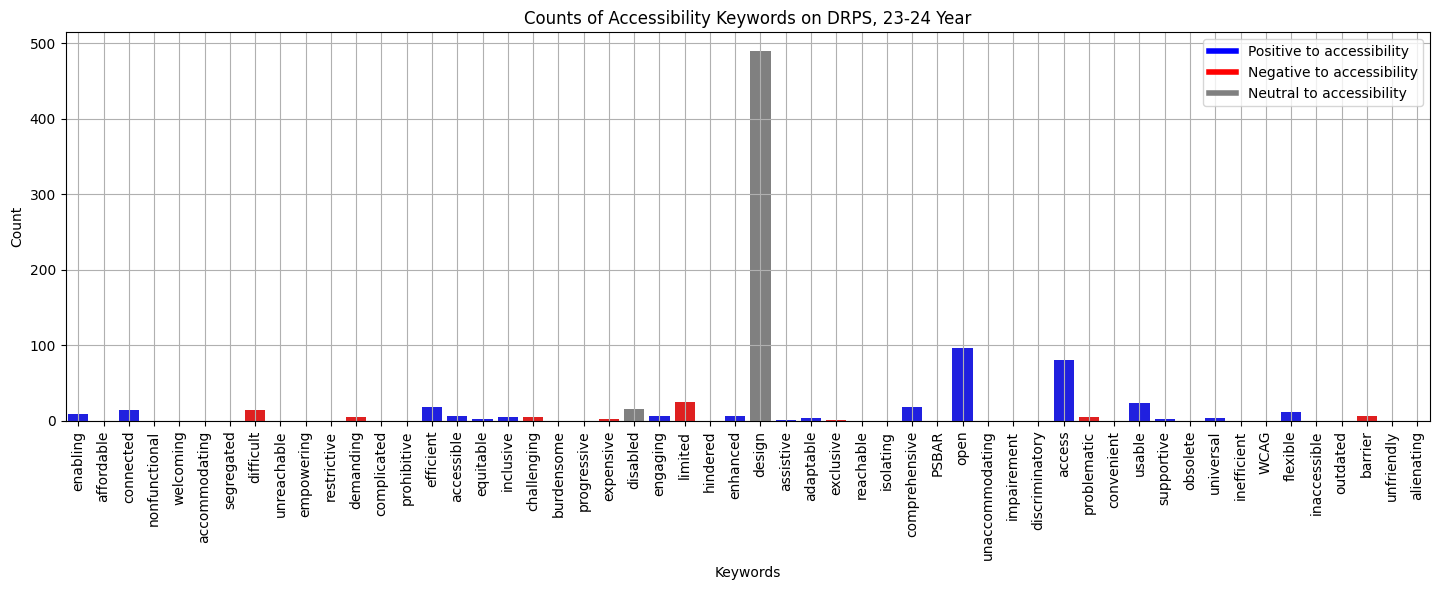

<Axes: title={'center': 'Counts of Accessibility Keywords on DRPS, 23-24 Year'}, xlabel='Keywords', ylabel='Count'>

In [2]:
# Example usage
directory = os.path.join(DIR_DATACONTAINER, DATA_VERSION)
plot_keyword_counts(directory, accessibility_dict['positive'], accessibility_dict['negative'])

#### Count the number of course containing accessibility information in 
 - "Summary", 
 - "Course description", 
 - "Learning Outcomes", 
 - "Graduate Attributes and Skills", 
 - "Keywords"

*Note: the semantic meaning analysis is done by Chatgpt-3.5 turbo*

In [3]:
# get number of courses in dic
data_version_dic = "./data_container/24_11_17_18_21_43/"
columntail_str = "-accessibility-evidences-output"
schoolurl_ls = os.listdir(data_version_dic)
schoolname_ls = [schoolurl_dic['_'.join(i.split('_')[1:]).replace('.csv', '')] for i in schoolurl_ls]

# initial dic
local_DRPS_values_of_interest = DRPS_values_of_interest.copy()
local_local_local_local_local_local_DRPS_values_of_interest = local_DRPS_values_of_interest.remove("Keywords")
school_dic = {}
df_ls = []
for school, schoolid in zip(schoolurl_ls, schoolname_ls):
    df = pd.read_csv(os.path.join(data_version_dic, school))
    df["School"] = schoolid
    school_dic[schoolid] = df[["School", "Course title"] + [''.join([i, columntail_str]) for i in local_DRPS_values_of_interest]]
    df_ls.append(school_dic[schoolid])

full_df = pd.concat(df_ls, axis=0, ignore_index=True)

In [4]:
print(f"Accessibility semantic meaning: {Chatbot_accessibility_words}")

Accessibility semantic meaning: Accessibility,Inclusive design,Disability rights,Adaptive tools


In [5]:
print(full_df.shape)
full_df.head()

(276, 6)


,School,Course title,Summary-accessibility-evidences-output,Course description-accessibility-evidences-output,Learning Outcomes-accessibility-evidences-output,Graduate Attributes and Skills-accessibility-evidences-output
0,School of Health in Social Science,Contemporary Issues in Health and Wellbeing (S...,"YES THERE IS Diversity in the topics covered, ...",YES THERE IS\n\nApproached,"YES THERE IS, partnership working through coll...",YES THERE IS - accessible way.
1,School of Health in Social Science,"Gender, Sexualities and Health (SHSS08008)","YES THERE IS: health, interdisciplinary, avail...",NO THERE IS NOT.,"YES THERE IS. In relation to ability, individu...",NO THERE ISNOT
2,School of Health in Social Science,Identity and Experience in Health (SHSS08002),NO THERE IS NOT.,"YES THERE IS ""patients as partners; empowermen...",NO THERE IS NOT,NO THERE ISNOT
3,School of Health in Social Science,Introduction to Disability Studies (Pre-Honour...,YES THERE IS 'opportunity for students to stud...,"YES THERE IS inclusive, flexible, blended, fle...","YES THERE IS ""demonstrate knowledge of the sco...","YES THERE IS engagement, equitable participati..."
4,School of Health in Social Science,Language and Communication in Health and Socie...,NO THERE ISNOT,YES THERE IS hands-on activities aimed at help...,YES THERE IS engage in the practice of listeni...,YES THERE IS communication clearly and accessi...


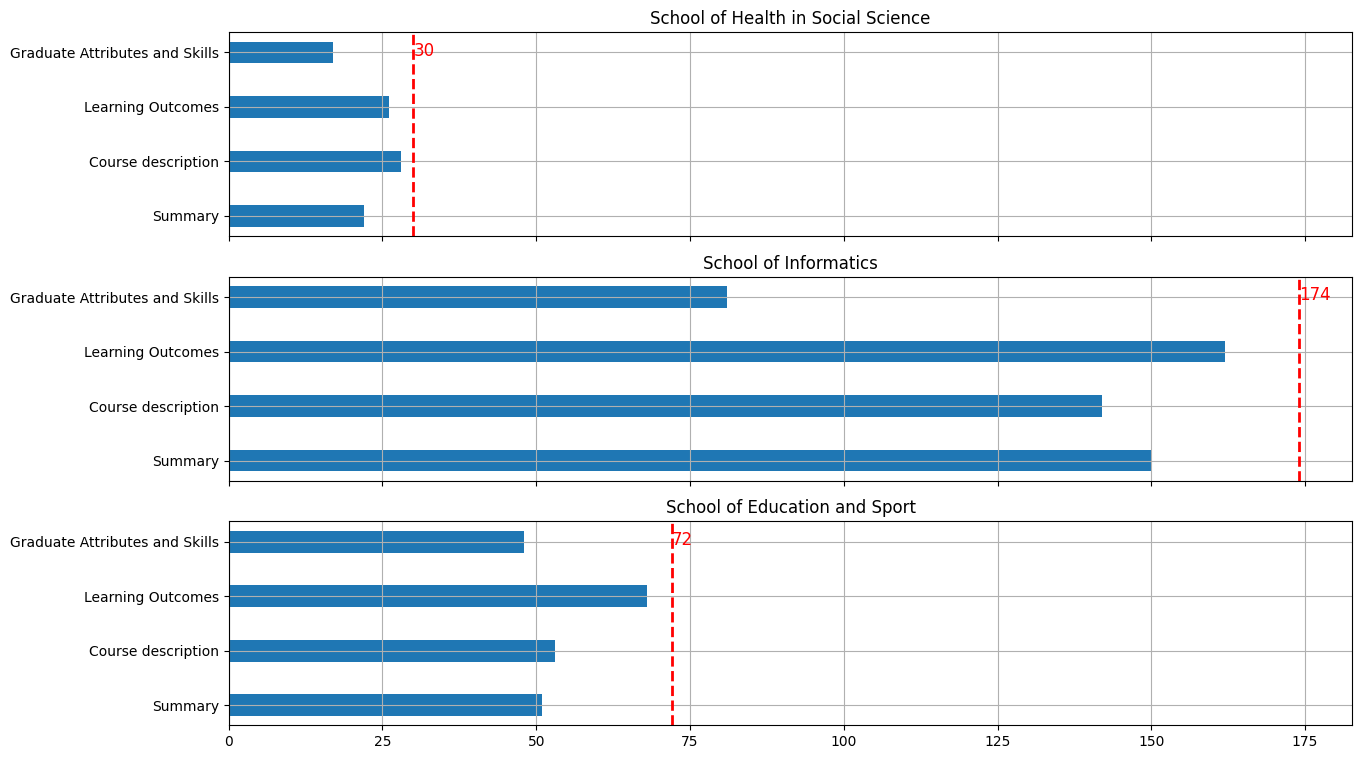

In [8]:
cols = full_df.columns
bar_width = 0.4
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=FIG_SIZE_VERTICAL, sharex=True)
for school, ax_sch in zip(schoolname_ls, [ax1, ax2, ax3]):
    school_attri = {}
    num_course_in_school = 0
    for col in [''.join([i, columntail_str]) for i in local_DRPS_values_of_interest]:
        school_df = full_df[full_df['School'] == school]
        num_course_in_school = len(school_df)
        subdf = school_df[school_df[col].str.contains("YES THERE")]
        num_have_YES = len(subdf)
        school_attri[col.replace(columntail_str, '')] = num_have_YES
    ax_sch.barh(list(school_attri.keys()), list(school_attri.values()), color='tab:blue', height=bar_width)
    ax_sch.axvline(x=num_course_in_school, color='red', linestyle='--', linewidth=2)

    # Adding the number next to the vertical line
    ax_sch.text(
        num_course_in_school,  # X-coordinate (aligned with the line)
        ax_sch.get_ylim()[1] * 0.95,  # Y-coordinate (slightly below the top of the plot)
        f"{num_course_in_school}",  # Text to display
        color='red',  # Color of the text
        fontsize=12,  # Font size
        ha='left',  # Horizontal alignment
        va='top'  # Vertical alignment
    )
    ax_sch.grid(True)
    ax_sch.set_title(school)
    ax_sch.set_yticklabels(list(school_attri.keys()))

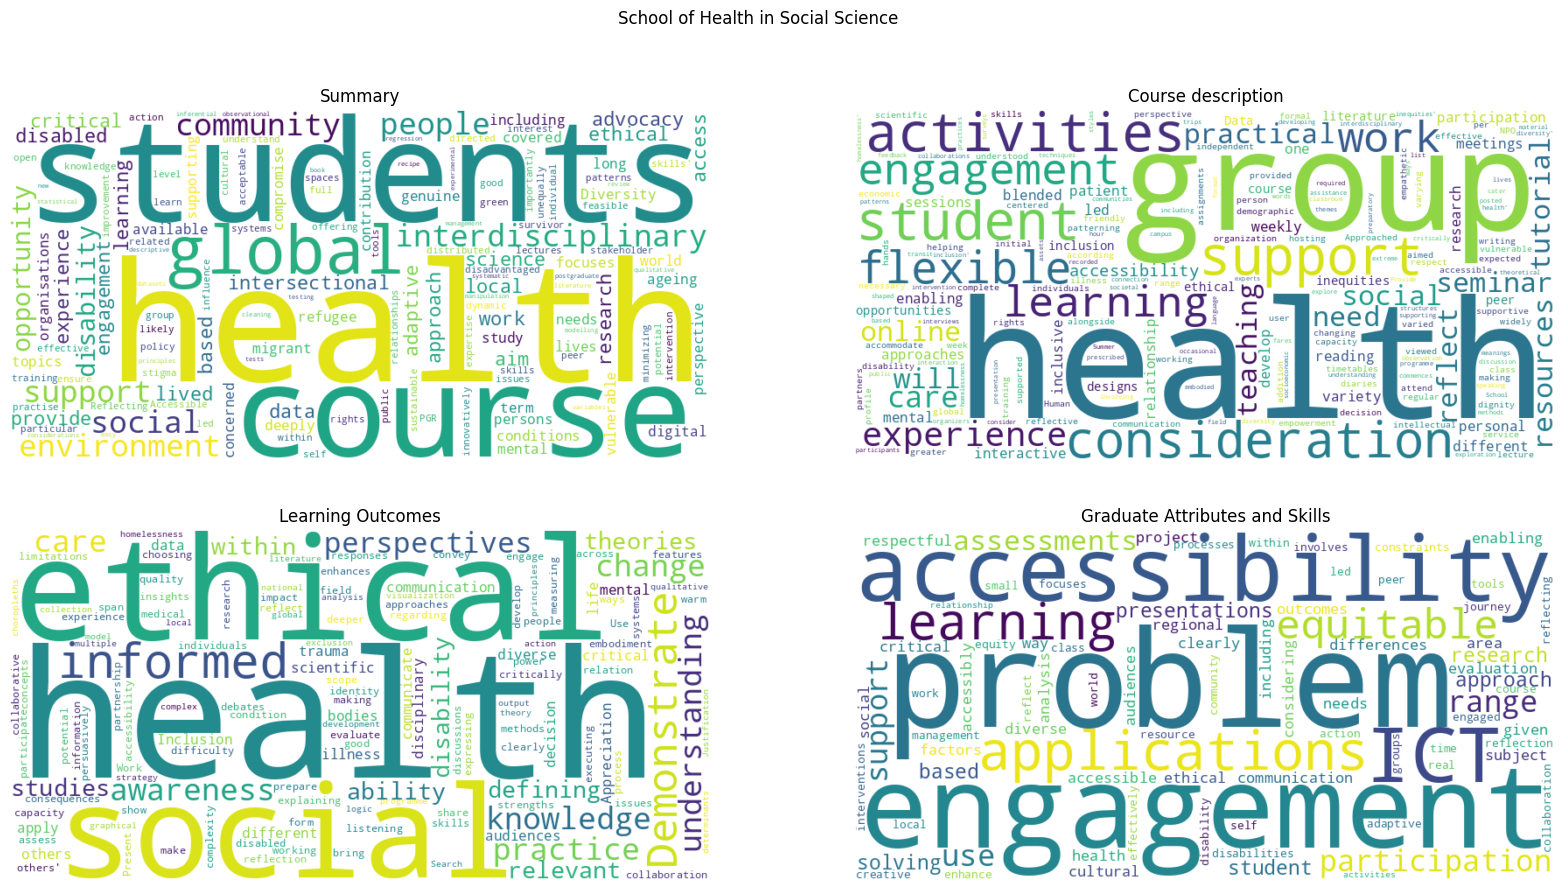

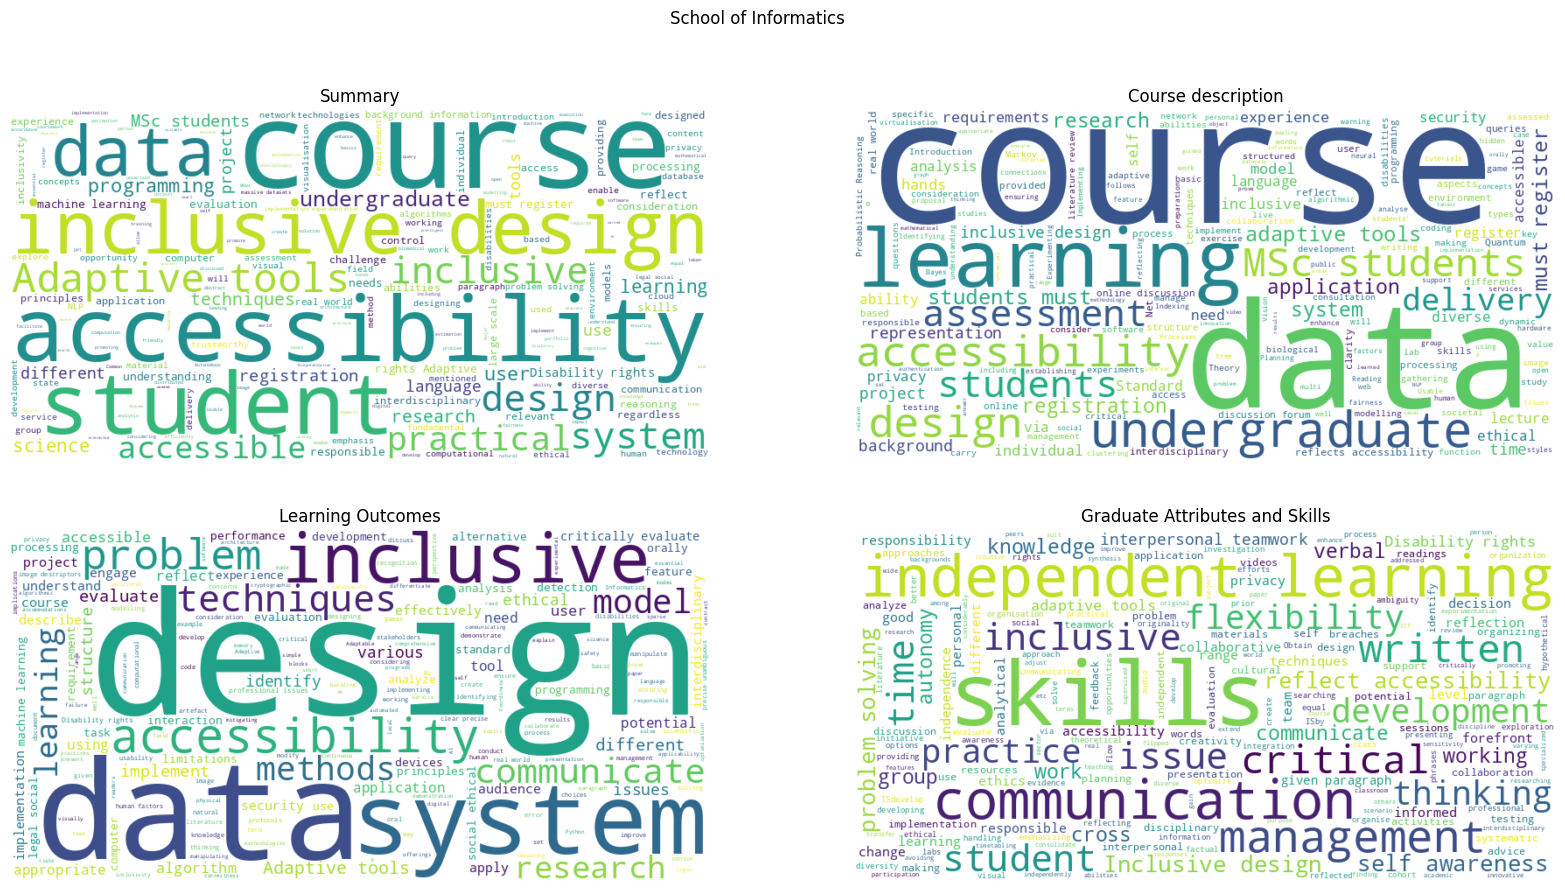

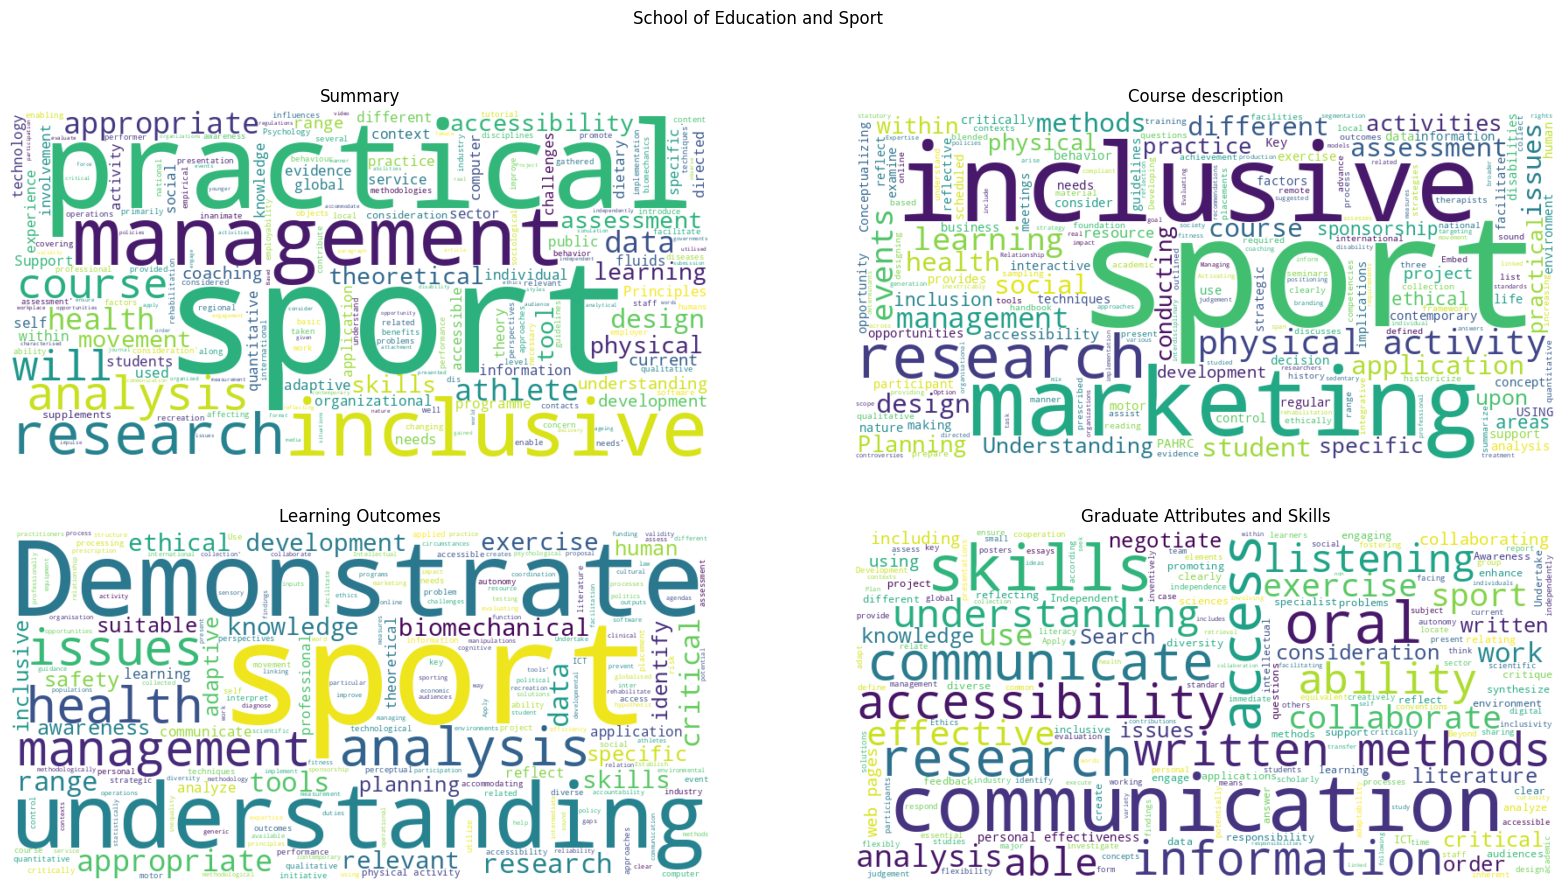

In [7]:
from wordcloud import WordCloud
FIG_SIZE_HUGE = (20, 10)
def plot_word_cloud(df_column, ax):
    # Convert the DataFrame column to a single string
    text = ' '.join(df_column.dropna().astype(str))  # Drop NA values and convert to string
    
    # Generate a word cloud image
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

    # Display the generated image using the provided Axes object:
    ax.imshow(wordcloud, interpolation='bilinear')
    ax.axis("off")  # Hide axis on the specific subplot

def filter_words(text):
    return ' '.join([word for word in text.split() if word not in words_to_remove])

words_to_remove = {'YES', 'THERE', 'IS'} | set(Chatbot_accessibility_words_ls)

for school in schoolname_ls:
    fig, axes = plt.subplots(2, int(len(local_DRPS_values_of_interest)/2), figsize=FIG_SIZE_HUGE)
    axes_ls = [i for i in axes.flatten()]
    fig.suptitle(school, fontsize=12)
    for col, ax_col in zip([''.join([i, columntail_str]) for i in local_DRPS_values_of_interest], axes_ls):
        school_df = full_df[full_df['School'] == school]
        subdf = school_df[school_df[col].str.contains("YES THERE")].copy()
        subdf[col] = subdf[col].apply(filter_words)
        ax_col.set_title(col.replace(columntail_str, ''))
        plot_word_cloud(subdf[col], ax_col)